# Import the Required Libraries

In [1726]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Cleaned Dataset

In [1727]:
df=pd.read_csv('cleaned_dataset.csv', encoding='latin1')

# Detailed Transformation Scenarios (15–20)

## 1. Exceedance flags vs daily/hourly standards

In [1728]:
df['PM2_5_flag_daily']=df['PM2_5']>df['Pollutant_standard_daily']
df['PM2_5_flag_hourly']=df['PM2_5']>df['Pollutant_standard_hourly']

In [1729]:
df['PM2_5_flag_daily'].head()

0    True
1    True
2    True
3    True
4    True
Name: PM2_5_flag_daily, dtype: bool

In [1730]:
df['PM2_5_flag_daily'].unique()

array([ True, False])

In [1731]:
ans={True:1,False:0}
df['PM2_5_flag_daily']=df['PM2_5_flag_daily'].map(ans)

In [1732]:
df['PM2_5_flag_daily'].unique()

array([1, 0])

In [1733]:
df['PM2_5_flag_daily']

0        1
1        1
2        1
3        1
4        1
        ..
14878    1
14879    1
14880    1
14881    1
14882    1
Name: PM2_5_flag_daily, Length: 14883, dtype: int64

In [1734]:
df['PM2_5_flag_hourly']=df['PM2_5_flag_hourly'].map(ans)

In [1735]:
df['PM2_5_flag_hourly'].unique()

array([1, 0])

In [1736]:
df['PM2_5_flag_hourly']

0        1
1        1
2        1
3        1
4        1
        ..
14878    1
14879    1
14880    1
14881    1
14882    0
Name: PM2_5_flag_hourly, Length: 14883, dtype: int64

In [1737]:
df['SO2_flag_daily']=df['SO2']>df['Pollutant_standard_daily']
df['SO2_flag_hourly']=df['SO2']>df['Pollutant_standard_hourly']


In [1738]:
df['SO2_flag_daily'].head()

0     True
1     True
2    False
3     True
4     True
Name: SO2_flag_daily, dtype: bool

In [1739]:
df['SO2_flag_daily'].unique()

array([ True, False])

In [1740]:
df['SO2_flag_daily']=df['SO2_flag_daily'].map(ans)

In [1741]:
df['SO2_flag_daily'].unique()

array([1, 0])

In [1742]:
df['SO2_flag_daily']

0        1
1        1
2        0
3        1
4        1
        ..
14878    0
14879    1
14880    0
14881    1
14882    0
Name: SO2_flag_daily, Length: 14883, dtype: int64

In [1743]:
df['SO2_flag_hourly']=df['SO2_flag_hourly'].map(ans)

In [1744]:
df['SO2_flag_hourly'].unique()

array([0, 1])

In [1745]:
df['SO2_flag_hourly']

0        0
1        1
2        0
3        1
4        1
        ..
14878    0
14879    1
14880    0
14881    1
14882    0
Name: SO2_flag_hourly, Length: 14883, dtype: int64

In [1746]:
df['NOx_flag_daily']=df['NOx']>df['Pollutant_standard_daily']
df['NOx_flag_hourly']=df['NOx']>df['Pollutant_standard_hourly']


In [1747]:
df['NOx_flag_daily'].head()

0    False
1     True
2    False
3     True
4     True
Name: NOx_flag_daily, dtype: bool

In [1748]:
df['NOx_flag_daily'].unique()

array([False,  True])

In [1749]:
df['NOx_flag_daily']=df['NOx_flag_daily'].map(ans)

In [1750]:
df['NOx_flag_daily'].unique()

array([0, 1])

In [1751]:
df['NOx_flag_daily']

0        0
1        1
2        0
3        1
4        1
        ..
14878    0
14879    1
14880    0
14881    1
14882    1
Name: NOx_flag_daily, Length: 14883, dtype: int64

In [1752]:
df['NOx_flag_hourly']=df['NOx_flag_hourly'].map(ans)

In [1753]:
df['NOx_flag_hourly'].unique()

array([0, 1])

In [1754]:
df['NOx_flag_hourly']

0        0
1        1
2        0
3        1
4        1
        ..
14878    0
14879    1
14880    0
14881    1
14882    0
Name: NOx_flag_hourly, Length: 14883, dtype: int64

In [1755]:
df.loc[1:10,['PM2_5','SO2','NOx','Pollutant_standard_daily','PM2_5_flag_daily','SO2_flag_daily','NOx_flag_daily','Pollutant_standard_hourly','PM2_5_flag_hourly','SO2_flag_hourly','NOx_flag_hourly']]

,PM2_5,SO2,NOx,Pollutant_standard_daily,PM2_5_flag_daily,SO2_flag_daily,NOx_flag_daily,Pollutant_standard_hourly,PM2_5_flag_hourly,SO2_flag_hourly,NOx_flag_hourly
1,83870.00,29840.00,35490.00,56.9,1,1,1,66.5,1,1,1
2,155.72,18.32,35.49,64.9,1,0,0,145.8,1,0,0
3,153280.00,62150.00,28010.00,40.3,1,1,1,107.4,1,1,1
4,71150.00,11060.00,122410.00,46.3,1,1,1,176.4,1,1,1
5,279.26,20.39,112.83,28.8,1,0,1,76.7,1,0,1
6,59.58,30.52,69.09,80.8,0,0,0,57.3,1,0,1
7,152.31,15.26,82.44,99.8,1,0,0,55.0,1,0,1
8,115640.00,13250.00,38920.00,67.4,1,1,1,133.7,1,1,1
9,117070.00,44240.00,35770.00,91.0,1,1,1,67.5,1,1,1
10,117070.00,29540.00,98540.00,90.4,1,1,1,191.2,1,1,1


## 2. Pollutant AQI sub‑index computation and overall AQI

In [1756]:
PM2_5_limit=60
SO2_limit=80
NOx_limit=80

In [1757]:
df['PM2_5_SubIndex']=((df['PM2_5']/[PM2_5_limit]) * 100).round(2)
df['SO2_SubIndex']=((df['SO2']/[SO2_limit]) * 100).round(2)
df['NOx_SubIndex']=((df['NOx']/[NOx_limit]) * 100).round(2)

In [1758]:
df['Overall_AQI']=df[['PM2_5_SubIndex','SO2_SubIndex','NOx_SubIndex']].max(axis=1)

In [1759]:
df.loc[1:10,['PM2_5','SO2','NOx','PM2_5_SubIndex','SO2_SubIndex','NOx_SubIndex','Overall_AQI']]

,PM2_5,SO2,NOx,PM2_5_SubIndex,SO2_SubIndex,NOx_SubIndex,Overall_AQI
1,83870.00,29840.00,35490.00,139783.33,37300.00,44362.50,139783.33
2,155.72,18.32,35.49,259.53,22.90,44.36,259.53
3,153280.00,62150.00,28010.00,255466.67,77687.50,35012.50,255466.67
4,71150.00,11060.00,122410.00,118583.33,13825.00,153012.50,153012.50
5,279.26,20.39,112.83,465.43,25.49,141.04,465.43
6,59.58,30.52,69.09,99.30,38.15,86.36,99.30
7,152.31,15.26,82.44,253.85,19.08,103.05,253.85
8,115640.00,13250.00,38920.00,192733.33,16562.50,48650.00,192733.33
9,117070.00,44240.00,35770.00,195116.67,55300.00,44712.50,195116.67
10,117070.00,29540.00,98540.00,195116.67,36925.00,123175.00,195116.67


## 3. Emission load (kg/day) from concentration and flow

In [1760]:
df["Flow_Rate"] = 1500

In [1761]:
df["PM2_5_Emission_Load"] = ((df["PM2_5"] * df["Flow_Rate"] * 24) / 10**9).round(4)
df["SO2_Emission_Load"] = ((df["SO2"] * df["Flow_Rate"] * 24) / 10**9).round(4)
df["NOx_Emission_Load"] = ((df["NOx"] * df["Flow_Rate"] * 24) / 10**9).round(4)

In [1762]:
df[["Flow_Rate", "PM2_5", "PM2_5_Emission_Load", "SO2", "SO2_Emission_Load", "NOx", "NOx_Emission_Load"]].head()

,Flow_Rate,PM2_5,PM2_5_Emission_Load,SO2,SO2_Emission_Load,NOx,NOx_Emission_Load
0,1500,157.84,0.0057,50.28,0.0018,26.06,0.0009
1,1500,83870.00,3.0193,29840.00,1.0742,35490.00,1.2776
2,1500,155.72,0.0056,18.32,0.0007,35.49,0.0013
3,1500,153280.00,5.5181,62150.00,2.2374,28010.00,1.0084
4,1500,71150.00,2.5614,11060.00,0.3982,122410.00,4.4068


## 4. Rolling 24‑hour averages and percentiles

In [1763]:
df['TS'].dtype

dtype('O')

In [1764]:
df["TS"] = pd.to_datetime(df["TS"])
df = df.sort_values(["Plant_ID", "TS"]).reset_index(drop=True)

In [1765]:
df["PM2_5_Rolling_Avg"] = (df.groupby("Plant_ID")["PM2_5"].rolling(window=24).mean().reset_index(level=0, drop=True)) 
df["PM2_5_Rolling_Avg"] = df["PM2_5_Rolling_Avg"].fillna(df["PM2_5"])

df["SO2_Rolling_Avg"] = (df.groupby("Plant_ID")["SO2"].rolling(window=24).mean().reset_index(level=0, drop=True))
df["SO2_Rolling_Avg"] = df["SO2_Rolling_Avg"].fillna(df["SO2"])

df["NOx_Rolling_Avg"] = (df.groupby("Plant_ID")["NOx"].rolling(window=24).mean().reset_index(level=0, drop=True))
df["NOx_Rolling_Avg"] = df["NOx_Rolling_Avg"].fillna(df["NOx"])

In [1766]:
df["PM2_5_25th_Percentile"] = df["PM2_5"].quantile(0.25)
df["PM2_5_50th_Percentile"] = df["PM2_5"].quantile(0.50)
df["PM2_5_75th_Percentile"] = df["PM2_5"].quantile(0.75)

df["SO2_25th_Percentile"] = df["SO2"].quantile(0.25)
df["SO2_50th_Percentile"] = df["SO2"].quantile(0.50)  
df["SO2_75th_Percentile"] = df["SO2"].quantile(0.75)

df["NOx_25th_Percentile"] = df["NOx"].quantile(0.25)
df["NOx_50th_Percentile"] = df["NOx"].quantile(0.50)
df["NOx_75th_Percentile"] = df["NOx"].quantile(0.75)

In [1767]:
df["PM2_5_75th_Percentile"].head(40)

0     88415.0
1     88415.0
2     88415.0
3     88415.0
4     88415.0
5     88415.0
6     88415.0
7     88415.0
8     88415.0
9     88415.0
10    88415.0
11    88415.0
12    88415.0
13    88415.0
14    88415.0
15    88415.0
16    88415.0
17    88415.0
18    88415.0
19    88415.0
20    88415.0
21    88415.0
22    88415.0
23    88415.0
24    88415.0
25    88415.0
26    88415.0
27    88415.0
28    88415.0
29    88415.0
30    88415.0
31    88415.0
32    88415.0
33    88415.0
34    88415.0
35    88415.0
36    88415.0
37    88415.0
38    88415.0
39    88415.0
Name: PM2_5_75th_Percentile, dtype: float64

In [1768]:
print(df[["Plant_ID","TS","PM2_5","PM2_5_Rolling_Avg","PM2_5_25th_Percentile","PM2_5_50th_Percentile","PM2_5_75th_Percentile"]].head())

  Plant_ID                  TS      PM2_5  PM2_5_Rolling_Avg  \
0    PL-01 2026-01-03 06:18:00     157.84             157.84   
1    PL-01 2026-01-03 11:59:00   83870.00           83870.00   
2    PL-01 2026-01-03 15:30:00     155.72             155.72   
3    PL-01 2026-01-03 15:35:00  153280.00          153280.00   
4    PL-01 2026-01-03 15:54:00   71150.00           71150.00   

   PM2_5_25th_Percentile  PM2_5_50th_Percentile  PM2_5_75th_Percentile  
0                  92.83                 186.01                88415.0  
1                  92.83                 186.01                88415.0  
2                  92.83                 186.01                88415.0  
3                  92.83                 186.01                88415.0  
4                  92.83                 186.01                88415.0  


In [1769]:
print(df[["Plant_ID","TS","SO2","SO2_Rolling_Avg","SO2_25th_Percentile","SO2_50th_Percentile","SO2_75th_Percentile"]].head())

  Plant_ID                  TS       SO2  SO2_Rolling_Avg  \
0    PL-01 2026-01-03 06:18:00     50.28            50.28   
1    PL-01 2026-01-03 11:59:00  29840.00         29840.00   
2    PL-01 2026-01-03 15:30:00     18.32            18.32   
3    PL-01 2026-01-03 15:35:00  62150.00         62150.00   
4    PL-01 2026-01-03 15:54:00  11060.00         11060.00   

   SO2_25th_Percentile  SO2_50th_Percentile  SO2_75th_Percentile  
0                25.99                47.31              25295.0  
1                25.99                47.31              25295.0  
2                25.99                47.31              25295.0  
3                25.99                47.31              25295.0  
4                25.99                47.31              25295.0  


In [1770]:
print(df[["Plant_ID","TS","NOx","NOx_Rolling_Avg","NOx_25th_Percentile","NOx_50th_Percentile","NOx_75th_Percentile"]].head())

  Plant_ID                  TS        NOx  NOx_Rolling_Avg  \
0    PL-01 2026-01-03 06:18:00      26.06            26.06   
1    PL-01 2026-01-03 11:59:00   35490.00         35490.00   
2    PL-01 2026-01-03 15:30:00      35.49            35.49   
3    PL-01 2026-01-03 15:35:00   28010.00         28010.00   
4    PL-01 2026-01-03 15:54:00  122410.00        122410.00   

   NOx_25th_Percentile  NOx_50th_Percentile  NOx_75th_Percentile  
0               38.495                72.92              35975.0  
1               38.495                72.92              35975.0  
2               38.495                72.92              35975.0  
3               38.495                72.92              35975.0  
4               38.495                72.92              35975.0  


## 5. Source contribution indicators (wind‑weighted).

In [1771]:
df['Wind_Weight_PM2_5']=(df['Wind_speed_m_s']*df['PM2_5']).round(2)
df['Wind_Weight_SO2']=(df['Wind_speed_m_s']*df['SO2']).round(2)
df['Wind_Weight_NOx']=(df['Wind_speed_m_s']*df['NOx']).round(2)

In [1772]:
df.loc[1:10,['PM2_5','Wind_Weight_PM2_5','SO2','Wind_Weight_SO2','NOx','Wind_Weight_NOx']]

,PM2_5,Wind_Weight_PM2_5,SO2,Wind_Weight_SO2,NOx,Wind_Weight_NOx
1,83870.00,410124.30,29840.00,145917.60,35490.00,173546.10
2,155.72,431.34,18.32,50.75,35.49,98.31
3,153280.00,1511340.80,62150.00,612799.00,28010.00,276178.60
4,71150.00,919969.50,11060.00,143005.80,122410.00,1582761.30
5,279.26,994.17,20.39,72.59,112.83,401.67
6,59.58,477.83,30.52,244.77,69.09,554.10
7,152.31,2238.96,15.26,224.32,82.44,1211.87
8,115640.00,1209594.40,13250.00,138595.00,38920.00,407103.20
9,117070.00,648567.80,44240.00,245089.60,35770.00,198165.80
10,117070.00,572472.30,29540.00,144450.60,98540.00,481860.60


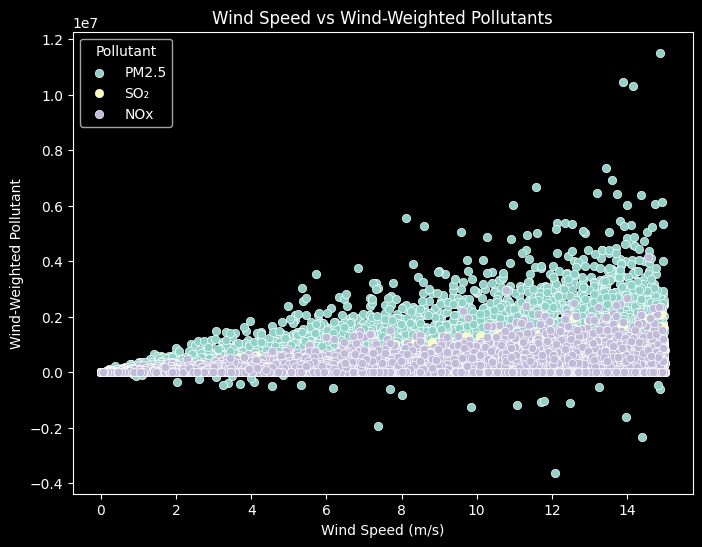

In [1773]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Wind_speed_m_s",
    y="Wind_Weight_PM2_5",
    label="PM2.5"
)

sns.scatterplot(
    data=df,
    x="Wind_speed_m_s",
    y="Wind_Weight_SO2",
    label="SO₂"
)

sns.scatterplot(
    data=df,
    x="Wind_speed_m_s",
    y="Wind_Weight_NOx",
    label="NOx"
)

plt.title("Wind Speed vs Wind-Weighted Pollutants")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Wind-Weighted Pollutant")
plt.legend(title="Pollutant")
plt.show()

## 6. Compliance rate per plant/month.

In [1774]:
df[["Plant_ID", "TS", "Compliance_Status"]].head()

,Plant_ID,TS,Compliance_Status
0,PL-01,2026-01-03 06:18:00,Exceeded
1,PL-01,2026-01-03 11:59:00,Exceeded
2,PL-01,2026-01-03 15:30:00,Exceeded
3,PL-01,2026-01-03 15:35:00,Exceeded
4,PL-01,2026-01-03 15:54:00,Exceeded


In [1775]:
df["Month"] = df["TS"].dt.to_period("M")

In [1776]:
compliance = (df.groupby(["Plant_ID", "Month"])["Compliance_Status"].apply(lambda x: (x == "Within Limit").mean() * 100).reset_index(name="Compliance_Rate (%)"))

In [1777]:
compliance["Compliance_Rate (%)"] = compliance["Compliance_Rate (%)"].round(2)

In [1778]:
compliance.head()

,Plant_ID,Month,Compliance_Rate (%)
0,PL-01,2026-01,19.05
1,PL-01,2026-02,38.71
2,PL-01,2026-03,34.71
3,PL-01,2026-04,37.50
4,PL-01,2026-05,57.89


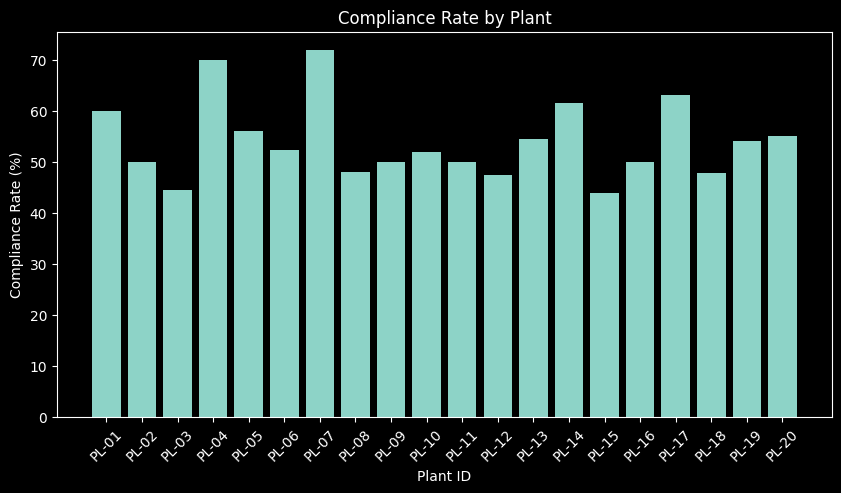

In [1779]:
plt.figure(figsize=(10,5))

plt.bar(
    compliance["Plant_ID"],
    compliance["Compliance_Rate (%)"]
)

plt.title("Compliance Rate by Plant")
plt.xlabel("Plant ID")
plt.ylabel("Compliance Rate (%)")
plt.xticks(rotation=45)

plt.show()

## 7. Episode detection (high pollution events).

In [1780]:
df['PM2_5_Status'].unique()

array(['Exceeded', 'Within Limit'], dtype=object)

In [1781]:
df['SO2_Status'].unique()

array(['Within Limit', 'Exceeded'], dtype=object)

In [1782]:
df['NOx_Status'].unique()

array(['Within Limit', 'Exceeded'], dtype=object)

In [1783]:
df['Pollution_Event']='Within Limit'
df['Pollution_Event']=(df['PM2_5_Status']=='Exceeded') | (df['SO2_Status']=='Exceeded') | (df['NOx_Status']=='Exceeded')

In [1784]:
df['Pollution_Event'].unique()

array([ True, False])

In [1785]:
df['Pollution_Event']=df['Pollution_Event'].replace(True,'High_Pollution_Event')
df['Pollution_Event']=df['Pollution_Event'].replace(False,'Within Limit')

In [1786]:
df['Pollution_Event']

0        High_Pollution_Event
1        High_Pollution_Event
2        High_Pollution_Event
3        High_Pollution_Event
4        High_Pollution_Event
                 ...         
14878    High_Pollution_Event
14879    High_Pollution_Event
14880    High_Pollution_Event
14881    High_Pollution_Event
14882            Within Limit
Name: Pollution_Event, Length: 14883, dtype: object

In [1787]:
df['Pollution_Event'].value_counts()

Pollution_Event
High_Pollution_Event    10010
Within Limit             4873
Name: count, dtype: int64

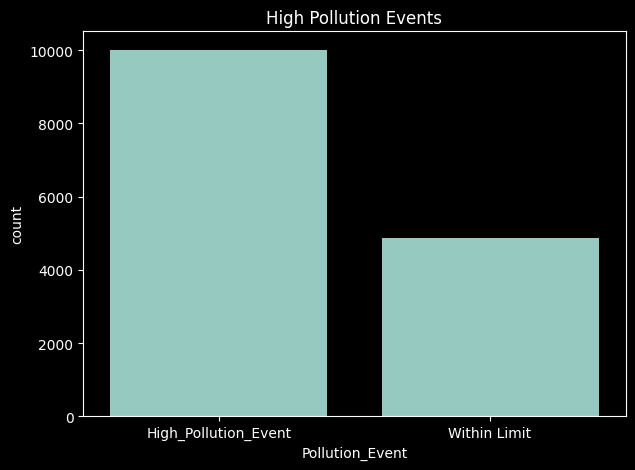

In [1788]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Pollution_Event")
plt.title("High Pollution Events")
plt.show()

## 8. Spatial interpolation grids for maps.

In [1789]:
df["Grid_Lat"] = df["Latitude"].round(1)
df["Grid_Lon"] = df["Longitude"].round(1)
grid_data = (df.groupby(["Grid_Lat", "Grid_Lon"])[["PM2_5", "SO2", "NOx"]].mean().reset_index())
grid_data.rename(columns={"PM2_5": "Average_PM2_5", "SO2": "Average_SO2", "NOx": "Average_NOx"}, inplace=True)

In [1790]:
print(grid_data.head(30))

    Grid_Lat  Grid_Lon  Average_PM2_5   Average_SO2   Average_NOx
0       13.1      78.0   48907.161194  14223.628196  20169.272202
1       13.3      80.3   47022.252375  12961.213228  18711.893780
2       13.3      81.7   48991.920410  12799.653956  17495.863700
3       13.5      76.0   46816.144846  12881.808692  18617.134179
4       13.6      78.5   49134.673644  11552.930279  18348.741024
5       13.9      77.0   51496.979625  13857.730161  20331.901005
6       13.9      78.6   53055.848799  14129.821389  19531.988611
7       14.2      76.6   48621.791536  13614.828971  21398.480964
8       14.2      77.5   49581.917693  13321.596343  20655.913696
9       14.2      77.6   50354.063492  12921.332288  20364.480106
10      14.3      78.5   53641.423236  13670.557724  19992.690228
11      14.4      79.6   48977.807867  13147.625212  18513.224492
12      14.7      80.6   45675.127027  13444.246110  18904.673288
13      14.9      81.7   51117.154535  13470.789255  19481.033324
14      15

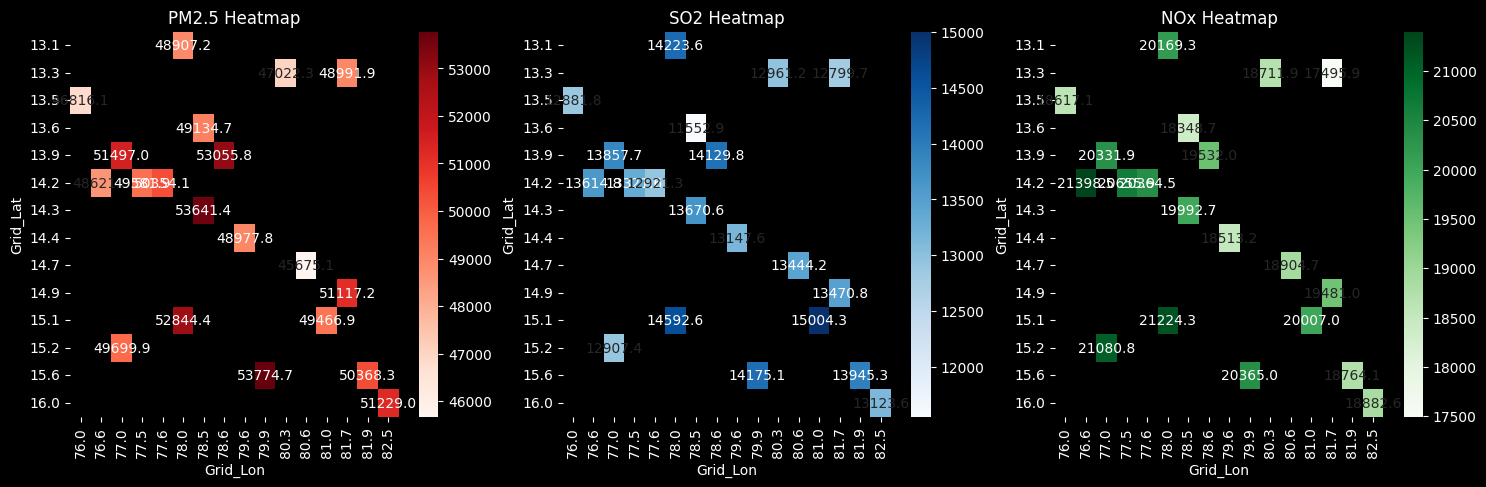

In [1791]:
pm = grid_data.pivot_table(values="Average_PM2_5", index="Grid_Lat", columns="Grid_Lon", aggfunc="mean")
so2 = grid_data.pivot_table(values="Average_SO2", index="Grid_Lat", columns="Grid_Lon", aggfunc="mean")
nox = grid_data.pivot_table(values="Average_NOx", index="Grid_Lat", columns="Grid_Lon", aggfunc="mean")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(pm, annot=True, cmap="Reds", fmt=".1f", ax=axes[0])
axes[0].set_title("PM2.5 Heatmap")

sns.heatmap(so2, annot=True, cmap="Blues", fmt=".1f", ax=axes[1])
axes[1].set_title("SO2 Heatmap")

sns.heatmap(nox, annot=True, cmap="Greens", fmt=".1f", ax=axes[2])
axes[2].set_title("NOx Heatmap")

plt.show()

## 9. Health risk proxy index (PM2.5 exposure).

In [1792]:
df['PM2_5'].head()

0       157.84
1     83870.00
2       155.72
3    153280.00
4     71150.00
Name: PM2_5, dtype: float64

In [1793]:
df['Health_Risk_Index']=np.where(
    df['PM2_5']<=15,1,
    np.where(
        df['PM2_5']<=35,2,
    np.where(
        df['PM2_5']<=55,3,
        np.where(
                df['PM2_5']<=100,4,5
            )
        )
    )
)

In [1794]:
risk_map = {
    1: "Low",
    2: "Moderate",
    3: "High",
    4: "Very High",
    5: "Hazardous"
}

In [1795]:
df["Health_Risk"] = df["Health_Risk_Index"].map(risk_map)

In [1796]:
df[['PM2_5','Health_Risk']]

,PM2_5,Health_Risk
0,157.84,Hazardous
1,83870.00,Hazardous
2,155.72,Hazardous
3,153280.00,Hazardous
4,71150.00,Hazardous
...,...,...
14878,262.14,Hazardous
14879,52090.00,Hazardous
14880,143.36,Hazardous
14881,182750.00,Hazardous


In [1797]:
df['Health_Risk'].value_counts()

Health_Risk
Hazardous    10716
Very High     2769
High           920
Moderate       393
Low             85
Name: count, dtype: int64

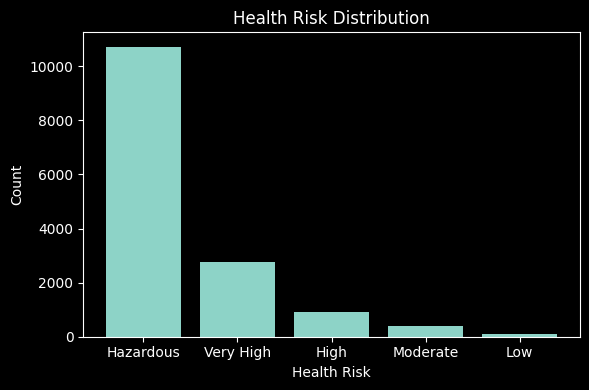

In [1798]:
risk = df["Health_Risk"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(risk.index, risk.values)

plt.title("Health Risk Distribution")
plt.xlabel("Health Risk")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 10. Diurnal and weekly seasonality profiles.

In [1799]:
df["Hour"] = df["TS"].dt.hour
df["Day"] = df["TS"].dt.day_name()

In [1800]:
hourly_profile = (df.groupby("Hour", as_index=False)[["PM2_5", "SO2", "NOx"]].mean())
weekly_profile = (df.groupby("Day", as_index=False)[["PM2_5", "SO2", "NOx"]].mean())

In [1801]:
print(weekly_profile, hourly_profile)

         Day         PM2_5           SO2           NOx
0     Friday  49210.902205  13233.748628  20893.349838
1     Monday  51352.509164  13397.623508  19586.054850
2   Saturday  49317.542677  13582.316843  19339.255279
3     Sunday  50314.782124  13258.746803  19381.619732
4   Thursday  46970.462521  13395.587242  18735.270188
5    Tuesday  51197.433000  13714.349996  19746.605611
6  Wednesday  51722.394370  13768.860966  19508.490442     Hour         PM2_5           SO2           NOx
0      0  48781.370359  13394.558709  19371.197614
1      1  50628.783546  12064.882745  17915.049003
2      2  57668.877424  16202.742957  22761.327742
3      3  45675.896576  13447.882237  19088.839373
4      4  46391.561871  13206.627565  19033.712161
5      5  44795.439857  14219.921240  17997.777456
6      6  51992.372864  13825.946377  20271.190854
7      7  51795.887549  13162.414302  20155.053831
8      8  49233.230304  12865.596438  19045.630822
9      9  50012.603958  13314.608029  19142.329386

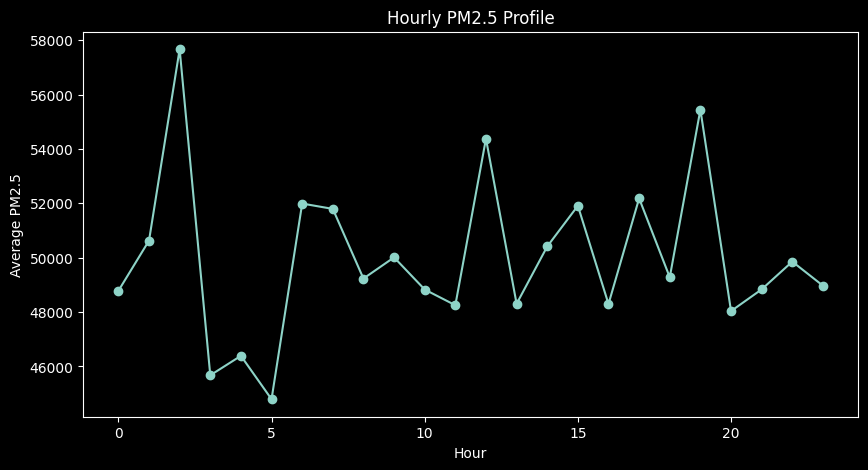

In [1802]:
plt.figure(figsize=(10,5))

plt.plot(hourly_profile["Hour"],
         hourly_profile["PM2_5"],
         marker="o")

plt.title("Hourly PM2.5 Profile")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5")
plt.show()

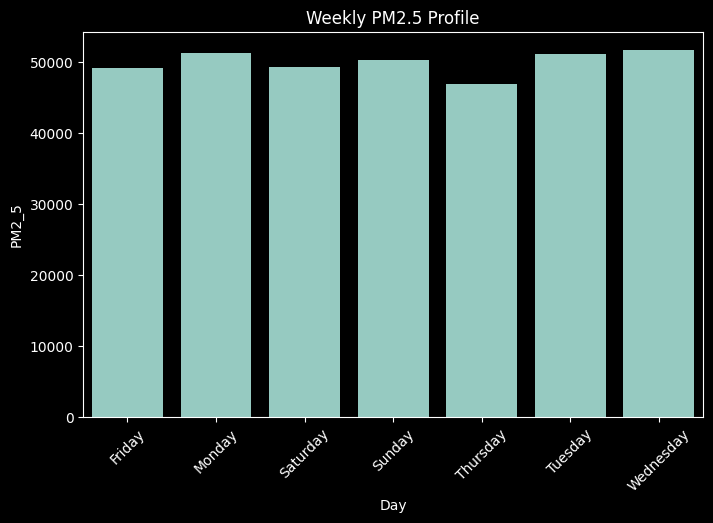

In [1803]:
plt.figure(figsize=(8,5))

sns.barplot(data=weekly_profile,
            x="Day",
            y="PM2_5")

plt.title("Weekly PM2.5 Profile")
plt.xticks(rotation=45)
plt.show()

## 11. Meteorology joins (wind, temp, RH).

In [1804]:
air_quality = df[[
    "TS",
    "Plant_ID",
    "PM2_5",
    "SO2",
    "NOx",
    "Overall_AQI"
]]

In [1805]:
meteorology = df[[
    "TS",
    "Wind_speed_m_s",
    "Wind_dir_deg",
    "Temp_C",
    "RH_pct"
]]

In [1806]:
pd.merge(air_quality,meteorology,on='TS',how='left')

,TS,Plant_ID,PM2_5,SO2,NOx,Overall_AQI,Wind_speed_m_s,Wind_dir_deg,Temp_C,RH_pct
0,2026-01-03 06:18:00,PL-01,157.84,50.28,26.06,263.07,12.91,161.1,39.3,56.5
1,2026-01-03 11:59:00,PL-01,83870.00,29840.00,35490.00,139783.33,4.89,48.1,25.7,78.2
2,2026-01-03 11:59:00,PL-01,83870.00,29840.00,35490.00,139783.33,3.65,18.8,40.1,34.6
3,2026-01-03 15:30:00,PL-01,155.72,18.32,35.49,259.53,2.77,98.4,23.1,74.5
4,2026-01-03 15:30:00,PL-01,155.72,18.32,35.49,259.53,3.28,195.3,21.9,74.4
...,...,...,...,...,...,...,...,...,...,...
19432,2026-12-04 02:23:00,PL-20,52090.00,41420.00,40990.00,86816.67,5.46,108.7,30.0,41.5
19433,2026-12-04 03:58:00,PL-20,143.36,67.99,29.64,238.93,0.06,264.8,37.0,23.6
19434,2026-12-04 04:20:00,PL-20,182750.00,27640.00,29640.00,304583.33,13.48,295.9,39.9,47.9
19435,2026-12-04 05:14:00,PL-20,74.63,47.47,77.67,124.38,1.15,73.9,20.2,45.9


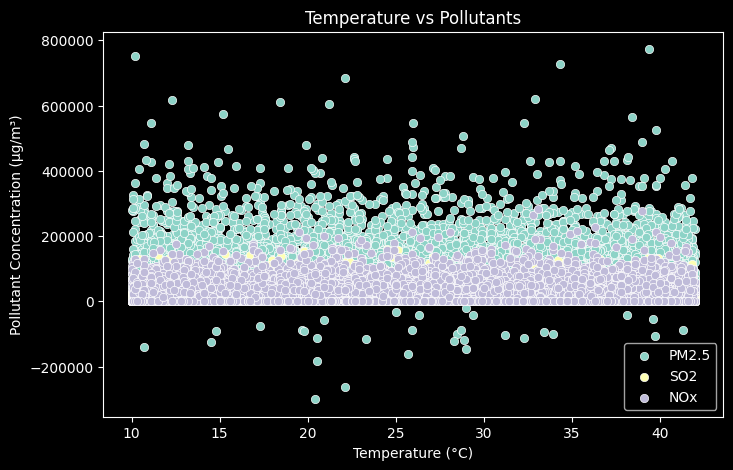

In [1807]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Temp_C", y="PM2_5", label="PM2.5")
sns.scatterplot(data=df, x="Temp_C", y="SO2", label="SO2")
sns.scatterplot(data=df, x="Temp_C", y="NOx", label="NOx")

plt.title("Temperature vs Pollutants")
plt.xlabel("Temperature (°C)")
plt.ylabel("Pollutant Concentration (µg/m³)")
plt.legend()
plt.show()

## 12. Emission factor application for sectors.

In [1808]:
df['Source_Type'].value_counts()

Source_Type
stack         8226
ambient       3645
lab           2280
inspection     732
Name: count, dtype: int64

In [1809]:
var = {'stack':1.2, 'ambient':0.7, 'lab':0.5, 'inspection':0.9}

In [1810]:
df['Emission_Factor']=df['Source_Type'].map(var)

In [1811]:
df['Emission_Factor'].head()

0    0.5
1    1.2
2    0.7
3    1.2
4    0.9
Name: Emission_Factor, dtype: float64

In [1812]:
df['Estimated_Emission_PM2_5']=(df['PM2_5'] * df['Emission_Factor']).round(2)
df['Estimated_Emission_SO2']=(df['SO2'] * df['Emission_Factor']).round(2)
df['Estimated_Emission_NOx']=(df['NOx'] * df['Emission_Factor']).round(2)

In [1813]:
df.loc[1:10,['Estimated_Emission_PM2_5','Estimated_Emission_SO2','Estimated_Emission_NOx']]

,Estimated_Emission_PM2_5,Estimated_Emission_SO2,Estimated_Emission_NOx
1,100644.00,35808.00,42588.00
2,109.00,12.82,24.84
3,183936.00,74580.00,33612.00
4,64035.00,9954.00,110169.00
5,195.48,14.27,78.98
6,41.71,21.36,48.36
7,182.77,18.31,98.93
8,138768.00,15900.00,46704.00
9,81949.00,30968.00,25039.00
10,140484.00,35448.00,118248.00


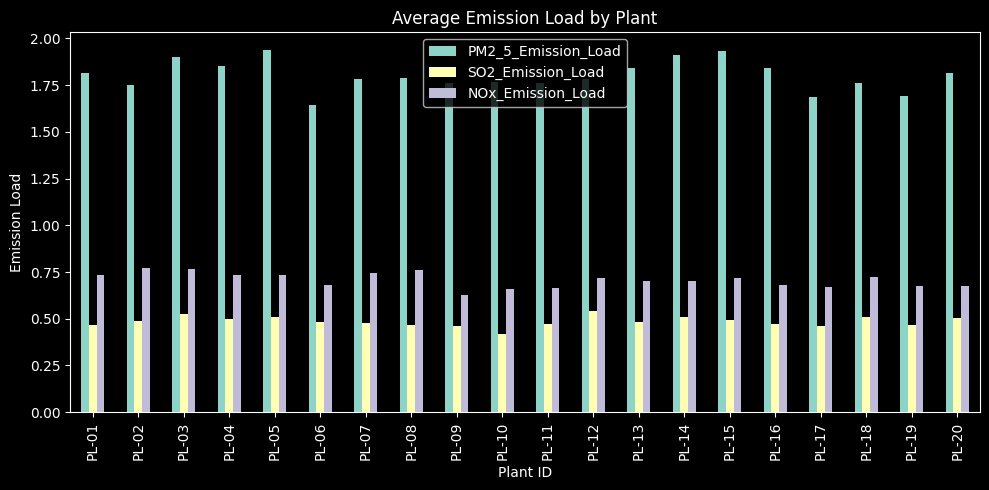

In [1814]:
emission = (df.groupby("Plant_ID")[["PM2_5_Emission_Load", "SO2_Emission_Load", "NOx_Emission_Load"]].mean())

emission.plot(kind="bar", figsize=(10,5))

plt.title("Average Emission Load by Plant")
plt.xlabel("Plant ID")
plt.ylabel("Emission Load")

plt.tight_layout()
plt.show()

## 13. Change‑point detection for drift alarms.

In [1815]:
df_sorted=df.sort_values(["Plant_ID", "TS"]).copy()

In [1816]:
df_sorted["PM2_5_Alarm"] = (df_sorted.groupby("Plant_ID")["PM2_5"].diff().round(2))
df_sorted["SO2_Alarm"] = (df_sorted.groupby("Plant_ID")["SO2"].diff().round(2))
df_sorted["NOx_Alarm"] = (df_sorted.groupby("Plant_ID")["NOx"].diff().round(2))

In [1817]:
min_limit = 20

In [1818]:
var={True:'No Alarm Needed', False:'Alarm Needed'}

In [1819]:
df_sorted["PM2_5_Alarm_Flag"] = (df_sorted["PM2_5_Alarm"] < min_limit).map(var)
df_sorted["SO2_Alarm_Flag"] = (df_sorted["SO2_Alarm"] < min_limit).map(var)
df_sorted["NOx_Alarm_Flag"] = (df_sorted["NOx_Alarm"] < min_limit).map(var)

In [1820]:
df_sorted.loc[100:200,["TS","PM2_5_Alarm", "PM2_5_Alarm_Flag","SO2_Alarm", "SO2_Alarm_Flag","NOx_Alarm", "NOx_Alarm_Flag"]].head()

,TS,PM2_5_Alarm,PM2_5_Alarm_Flag,SO2_Alarm,SO2_Alarm_Flag,NOx_Alarm,NOx_Alarm_Flag
100,2026-03-13 18:06:00,-135297.76,No Alarm Needed,-21390.70,No Alarm Needed,-48853.14,No Alarm Needed
101,2026-03-13 19:30:00,94.35,Alarm Needed,-0.47,No Alarm Needed,-42.82,No Alarm Needed
102,2026-03-13 19:36:00,45393.41,Alarm Needed,28801.17,Alarm Needed,83435.96,Alarm Needed
103,2026-03-13 21:28:00,-45332.50,No Alarm Needed,-28815.41,No Alarm Needed,-83445.35,No Alarm Needed
104,2026-03-14 00:02:00,77272.50,Alarm Needed,19945.41,Alarm Needed,29955.35,Alarm Needed


## 14. Gap‑filled vs raw comparison metrics.

In [1821]:
df_raw=pd.read_csv('pollution_raw_data.csv')

In [1822]:
df_raw[['PM2_5','SO2','NOx']].isnull().sum()

PM2_5    307
SO2      324
NOx      280
dtype: int64

In [1823]:
df_raw["PM2_5_Raw"] = df_raw["PM2_5"]
df_raw["SO2_Raw"] = df_raw["SO2"]
df_raw["NOx_Raw"] = df_raw["NOx"]

df_raw["PM2_5_Filled"] = df_raw["PM2_5"].fillna(df_raw["PM2_5"].mean())
df_raw["SO2_Filled"] = df_raw["SO2"].fillna(df_raw["SO2"].mean())
df_raw["NOx_Filled"] = df_raw["NOx"].fillna(df_raw["NOx"].mean())

df_raw["PM2_5_Status"] = np.where(df_raw["PM2_5_Raw"].isna(), "Gap Filled", "No Change")
df_raw["SO2_Status"] = np.where(df_raw["SO2_Raw"].isna(), "Gap Filled", "No Change")
df_raw["NOx_Status"] = np.where(df_raw["NOx_Raw"].isna(), "Gap Filled", "No Change")

In [1824]:
print(df_raw[["Plant_ID","PM2_5_Raw", "PM2_5_Filled", "PM2_5_Status","SO2_Raw", "SO2_Filled", "SO2_Status","NOx_Raw", "NOx_Filled", "NOx_Status"]].head(30))

   Plant_ID  PM2_5_Raw  PM2_5_Filled PM2_5_Status    SO2_Raw  SO2_Filled  \
0     PL-11     59.101     59.101000    No Change     39.112      39.112   
1     PL-05     83.134     83.134000    No Change     26.186      26.186   
2     PL-10    299.073    299.073000    No Change     59.344      59.344   
3     PL-04     39.035     39.035000    No Change     24.661      24.661   
4     PL-06    146.540    146.540000    No Change     47.534      47.534   
5     PL-18    127.864    127.864000    No Change     30.846      30.846   
6     PL-19    441.111    441.111000    No Change     14.619      14.619   
7     PL-18    129.840    129.840000    No Change     42.299      42.299   
8     PL-18    123.836    123.836000    No Change  99999.000   99999.000   
9     PL-16     68.047     68.047000    No Change     59.063      59.063   
10    PL-15        NaN    138.556204   Gap Filled     49.033      49.033   
11    PL-09        NaN    138.556204   Gap Filled     80.659      80.659   
12    PL-15 

In [1825]:
df_raw["PM2_5_Status"].value_counts()

PM2_5_Status
No Change     14943
Gap Filled      307
Name: count, dtype: int64

In [1826]:
df_raw["SO2_Status"].value_counts()

SO2_Status
No Change     14926
Gap Filled      324
Name: count, dtype: int64

In [1827]:
df_raw["NOx_Status"].value_counts()

NOx_Status
No Change     14970
Gap Filled      280
Name: count, dtype: int64

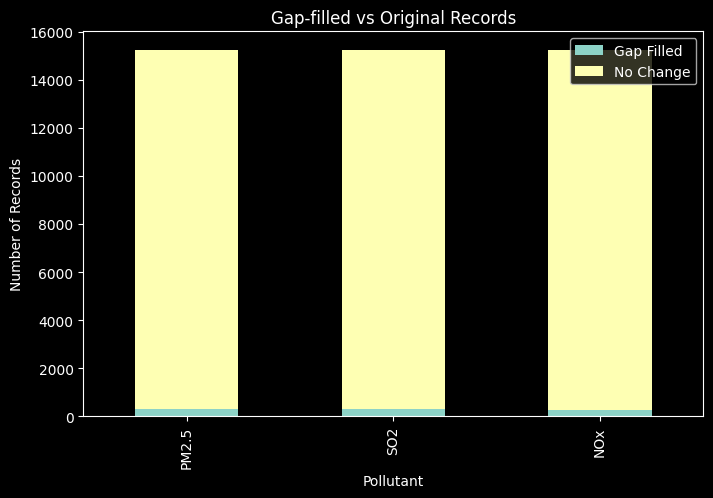

In [1828]:
gap_summary = pd.DataFrame({
    "Pollutant": ["PM2.5", "SO2", "NOx"],
    "Gap Filled": [
        df_raw["PM2_5"].isna().sum(),
        df_raw["SO2"].isna().sum(),
        df_raw["NOx"].isna().sum()
    ]
})

gap_summary["No Change"] = len(df_raw) - gap_summary["Gap Filled"]

gap_summary.set_index("Pollutant").plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Gap-filled vs Original Records")
plt.xlabel("Pollutant")
plt.ylabel("Number of Records")
plt.show()

## 15. Regulatory reporting tables (Stack, Ambient).

In [1829]:
stack = df[df["Source_Type"]=="stack"]

In [1830]:
stack_report = stack.groupby("Plant_ID")[["PM2_5","SO2","NOx"]].mean().round(2)

In [1831]:
ambient = df[df["Source_Type"]=="ambient"]

In [1832]:
ambient_report = ambient.groupby("Plant_ID")[["PM2_5","SO2","NOx"]].mean().round(2)

In [1833]:
report = pd.merge(stack_report, ambient_report, on="Plant_ID", how="outer", suffixes=("_Stack", "_Ambient"))

In [1834]:
report

,PM2_5_Stack,SO2_Stack,NOx_Stack,PM2_5_Ambient,SO2_Ambient,NOx_Ambient
Plant_ID,,,,,,
PL-01,45994.59,12672.01,18230.51,58085.12,12611.68,21010.88
PL-02,48578.50,13582.51,21217.67,47628.28,14286.79,22132.19
PL-03,52914.25,14211.59,21137.09,55303.33,14626.66,22724.38
PL-04,44324.89,12702.22,19150.54,57299.41,15038.37,23338.22
PL-05,51568.48,13895.11,19802.38,60188.26,14047.47,19908.60
PL-06,44222.01,13088.31,19166.12,43820.81,14515.00,19431.33
PL-07,50426.70,13803.00,21391.84,37885.66,11090.40,15907.44
PL-08,49486.00,12033.35,20474.63,53561.00,15769.52,24325.07
PL-09,46131.99,11676.62,16745.01,51105.26,13768.54,17744.22


## 16. Model features for forecasting PM2.5.

In [1835]:
df = df.sort_values(["Plant_ID", "TS"])

In [1836]:
df["PM2_5_Lag_1"] = df.groupby("Plant_ID")["PM2_5"].shift(1)
df["PM2_5_Lag_2"] = df.groupby("Plant_ID")["PM2_5"].shift(2)

In [1837]:
df["PM2_5_Rolling_Mean_3"] = (df.groupby("Plant_ID")["PM2_5"].transform(lambda x: x.rolling(window=3, min_periods=1).mean()))
df["PM2_5_Rolling_STD_3"] = (df.groupby("Plant_ID")["PM2_5"].transform(lambda x: x.rolling(window=3, min_periods=1).std()).fillna(0))

In [1838]:
df["Is_Weekend"] = df["TS"].dt.dayofweek.isin([5, 6]).astype(int)
df[["Plant_ID", "TS", "PM2_5", "PM2_5_Lag_1", "PM2_5_Lag_2", "PM2_5_Rolling_Mean_3", "PM2_5_Rolling_STD_3", "Hour", "Day", "Month", "Is_Weekend"]].head()

,Plant_ID,TS,PM2_5,PM2_5_Lag_1,PM2_5_Lag_2,PM2_5_Rolling_Mean_3,PM2_5_Rolling_STD_3,Hour,Day,Month,Is_Weekend
0,PL-01,2026-01-03 06:18:00,157.84,NaN,NaN,157.840000,0.000000,6,Saturday,2026-01,1
1,PL-01,2026-01-03 11:59:00,83870.00,157.84,NaN,42013.920000,59193.436004,11,Saturday,2026-01,1
2,PL-01,2026-01-03 15:30:00,155.72,83870.00,157.84,28061.186667,48331.850113,15,Saturday,2026-01,1
3,PL-01,2026-01-03 15:35:00,153280.00,155.72,83870.00,79101.906667,76673.413364,15,Saturday,2026-01,1
4,PL-01,2026-01-03 15:54:00,71150.00,153280.00,155.72,74861.906667,76629.595912,15,Saturday,2026-01,1


## 17. Hotspot ranking by persistence and intensity.

In [1839]:
pm_limit = 60
so2_limit = 80
nox_limit = 80

In [1840]:
df["PM2_5_Hotspot"] = df["PM2_5"] > pm_limit
df["SO2_Hotspot"] = df["SO2"] > so2_limit
df["NOx_Hotspot"] = df["NOx"] > nox_limit

In [1841]:
pm_intensity = df.groupby("Plant_ID")["PM2_5"].mean().round(2)
so2_intensity = df.groupby("Plant_ID")["SO2"].mean().round(2)
nox_intensity = df.groupby("Plant_ID")["NOx"].mean().round(2)

In [1842]:
pm_persistence = df.groupby("Plant_ID")["PM2_5_Hotspot"].sum()
so2_persistence = df.groupby("Plant_ID")["SO2_Hotspot"].sum()
nox_persistence = df.groupby("Plant_ID")["NOx_Hotspot"].sum()

In [1843]:
hotspot_report = pd.DataFrame({"PM2_5_Intensity": pm_intensity, "PM2_5_Persistence": pm_persistence, "SO2_Intensity": so2_intensity, "SO2_Persistence": so2_persistence, "NOx_Intensity": nox_intensity, "NOx_Persistence": nox_persistence})

In [1844]:
hotspot_report.head()

,PM2_5_Intensity,PM2_5_Persistence,SO2_Intensity,SO2_Persistence,NOx_Intensity,NOx_Persistence
Plant_ID,,,,,,
PL-01,50354.06,658,12921.33,309,20364.48,363
PL-02,48621.79,687,13614.83,321,21398.48,374
PL-03,52844.36,643,14592.56,315,21224.33,363
PL-04,51496.98,667,13857.73,315,20331.90,351
PL-05,53774.67,664,14175.10,311,20365.03,355


In [1845]:
hotspot_report.index.value_counts()

Plant_ID
PL-01    1
PL-02    1
PL-03    1
PL-04    1
PL-05    1
PL-06    1
PL-07    1
PL-08    1
PL-09    1
PL-10    1
PL-11    1
PL-12    1
PL-13    1
PL-14    1
PL-15    1
PL-16    1
PL-17    1
PL-18    1
PL-19    1
PL-20    1
Name: count, dtype: int64

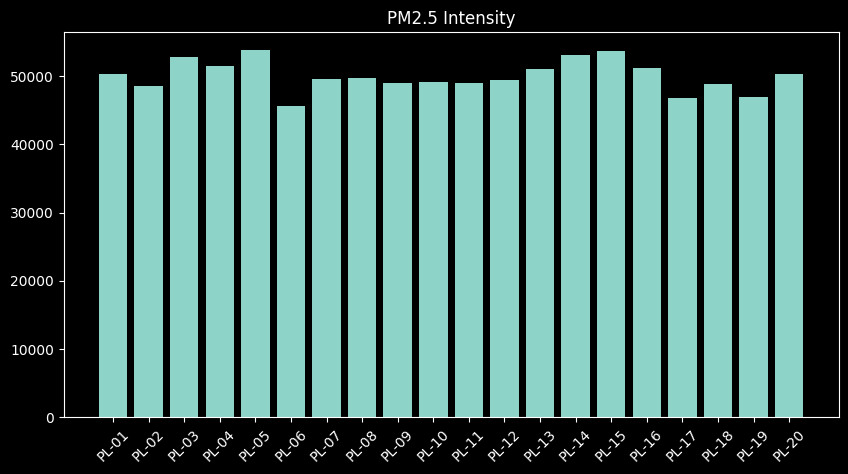

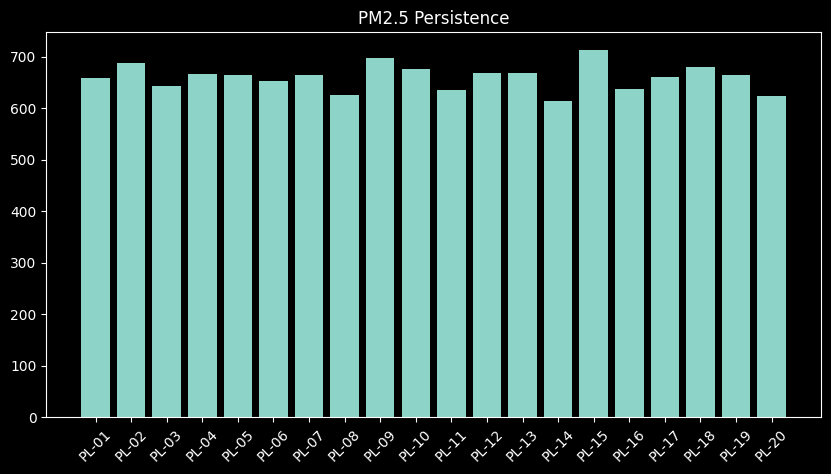

In [1846]:
plt.figure(figsize=(10,5))
plt.bar(hotspot_report.index, hotspot_report["PM2_5_Intensity"])
plt.title("PM2.5 Intensity")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(hotspot_report.index, hotspot_report["PM2_5_Persistence"])
plt.title("PM2.5 Persistence")
plt.xticks(rotation=45)
plt.show()

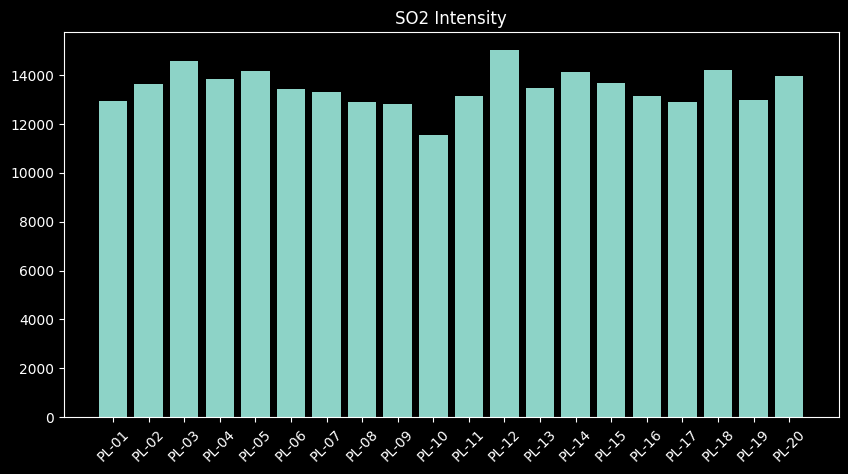

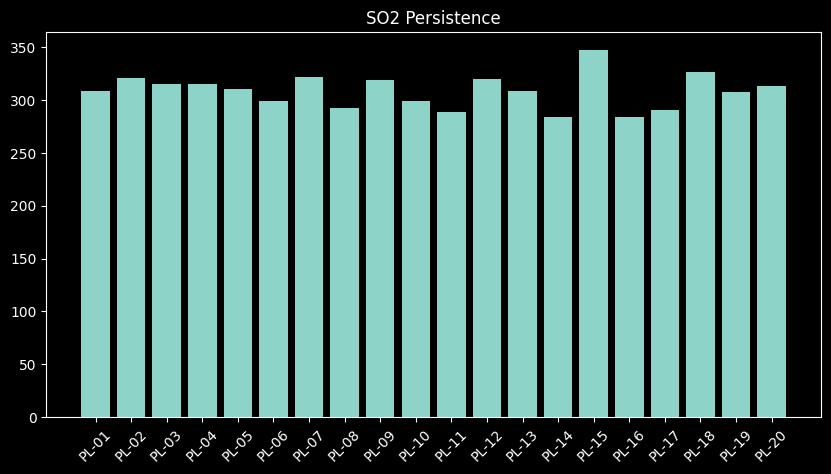

In [1847]:
plt.figure(figsize=(10,5))
plt.bar(hotspot_report.index, hotspot_report["SO2_Intensity"])
plt.title("SO2 Intensity")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(hotspot_report.index, hotspot_report["SO2_Persistence"])
plt.title("SO2 Persistence")
plt.xticks(rotation=45)
plt.show()

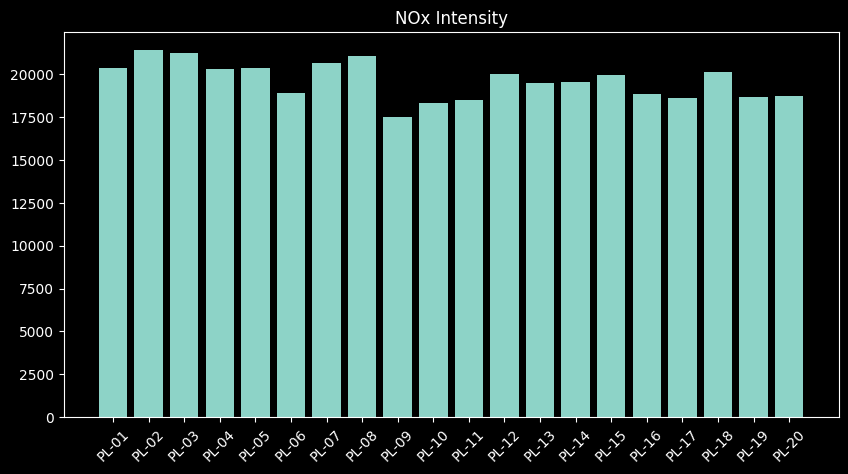

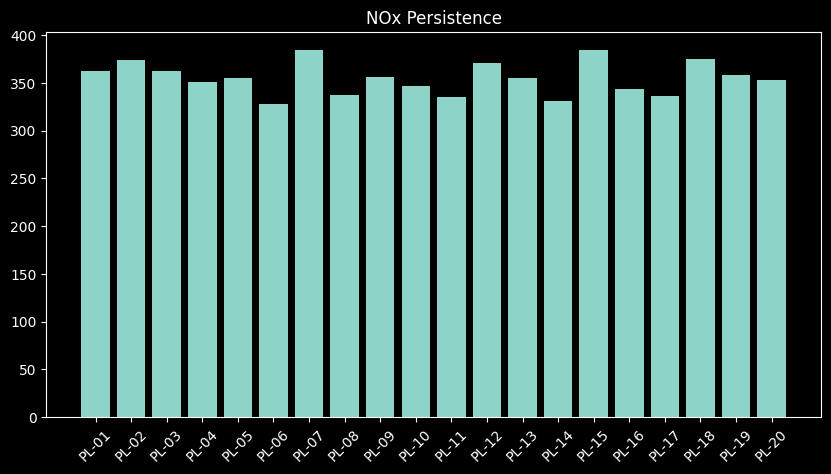

In [1848]:
plt.figure(figsize=(10,5))
plt.bar(hotspot_report.index, hotspot_report["NOx_Intensity"])
plt.title("NOx Intensity")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(hotspot_report.index, hotspot_report["NOx_Persistence"])
plt.title("NOx Persistence")
plt.xticks(rotation=45)
plt.show()

## 18. Control measure impact evaluation (pre/post).

In [1849]:
df["Period"] = df["TS"].dt.month.apply(lambda x: "Before" if x <= 6 else "After")

In [1850]:
impact = (df.groupby("Period")[["PM2_5", "SO2", "NOx"]].mean().round(2).reset_index())

In [1851]:
before = impact[impact["Period"] == "Before"].iloc[0]
after = impact[impact["Period"] == "After"].iloc[0]

In [1852]:
comparison = pd.DataFrame({"Pollutant": ["PM2_5", "SO2", "NOx"], "Before": [before["PM2_5"], before["SO2"], before["NOx"]], "After": [after["PM2_5"], after["SO2"], after["NOx"]]})

In [1853]:
comparison["Percent_Change"] = ((comparison["After"] - comparison["Before"])/ comparison["Before"] * 100).round(2)


In [1854]:
comparison

,Pollutant,Before,After,Percent_Change
0,PM2_5,50367.46,48601.41,-3.51
1,SO2,13553.89,13182.39,-2.74
2,NOx,19650.19,19601.07,-0.25


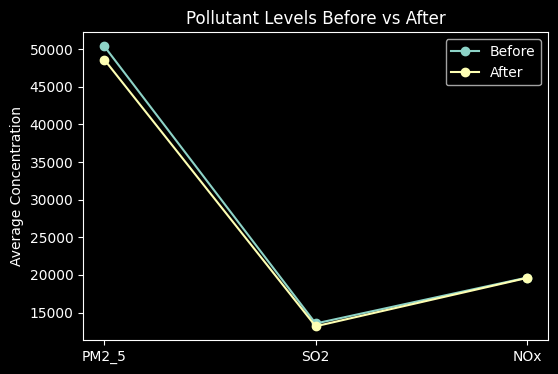

In [1855]:
plt.figure(figsize=(6,4))

plt.plot(comparison["Pollutant"], comparison["Before"], marker="o", label="Before")
plt.plot(comparison["Pollutant"], comparison["After"], marker="o", label="After")

plt.title("Pollutant Levels Before vs After")
plt.ylabel("Average Concentration")
plt.legend()

plt.show()

## 19. Compliance penalty estimation.

In [1856]:
df['Penalty']=0

In [1857]:
df["Penalty"] += np.where(df["PM2_5"] > 60, 5000, 0)
df["Penalty"] += np.where(df["SO2"] > 80, 3000, 0)
df["Penalty"] += np.where(df["NOx"] > 80, 3000, 0)

In [1858]:
df[["Plant_ID", "PM2_5", "SO2", "NOx", "Penalty"]].head()

,Plant_ID,PM2_5,SO2,NOx,Penalty
0,PL-01,157.84,50.28,26.06,5000
1,PL-01,83870.00,29840.00,35490.00,11000
2,PL-01,155.72,18.32,35.49,5000
3,PL-01,153280.00,62150.00,28010.00,11000
4,PL-01,71150.00,11060.00,122410.00,11000


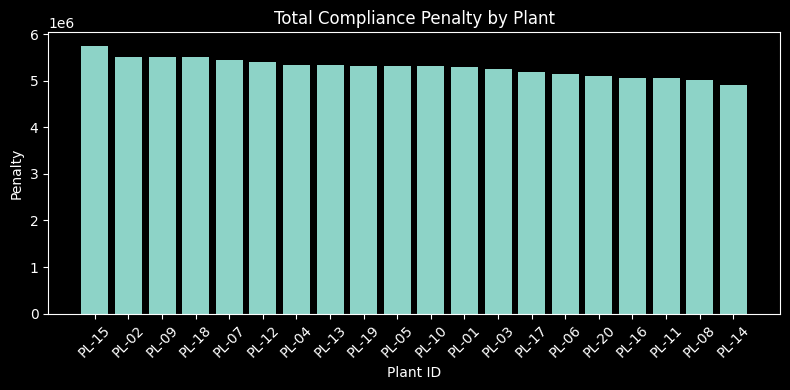

In [1859]:
penalty_summary = (
    df.groupby("Plant_ID")["Penalty"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))
plt.bar(penalty_summary.index, penalty_summary.values)

plt.title("Total Compliance Penalty by Plant")
plt.xlabel("Plant ID")
plt.ylabel("Penalty")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 20. Open data extract with privacy safeguards.

In [1860]:
public_data = df.copy()

In [1861]:
public_data = public_data.drop(columns=[
    "Sensor_serial",
    "Analyst_ID",
    "Audit_Trail",
    "Inspector_notes"
])

In [1862]:
public_data.head(30)

,Plant_ID,TS,Record_ID,Stack_ID,Source_Type,PM2_5,SO2,NOx,Unit,LatLon,...,PM2_5_Lag_1,PM2_5_Lag_2,PM2_5_Rolling_Mean_3,PM2_5_Rolling_STD_3,Is_Weekend,PM2_5_Hotspot,SO2_Hotspot,NOx_Hotspot,Period,Penalty
0,PL-01,2026-01-03 06:18:00,E100013,ST-008,lab,157.84,50.28,26.06,ug/m3,"14.2265, 77.6492",...,NaN,NaN,157.840000,0.000000,1,True,False,False,Before,5000
1,PL-01,2026-01-03 11:59:00,E100124,ST-002,stack,83870.00,29840.00,35490.00,ug/m3,"14.2265, 77.6492",...,157.84,NaN,42013.920000,59193.436004,1,True,True,True,Before,11000
2,PL-01,2026-01-03 15:30:00,E100193,ST-002,ambient,155.72,18.32,35.49,ug/m3,"14.2265, 77.6492",...,83870.00,157.84,28061.186667,48331.850113,1,True,False,False,Before,5000
3,PL-01,2026-01-03 15:35:00,E100197,ST-002,stack,153280.00,62150.00,28010.00,ug/m3,"14.2265, 77.6492",...,155.72,83870.00,79101.906667,76673.413364,1,True,True,True,Before,11000
4,PL-01,2026-01-03 15:54:00,E100207,ST-002,inspection,71150.00,11060.00,122410.00,ug/m3,"14.2265, 77.6492",...,153280.00,155.72,74861.906667,76629.595912,1,True,True,True,Before,11000
5,PL-01,2026-01-03 16:25:00,E100216,ST-008,ambient,279.26,20.39,112.83,ug/m3,"14.2265, 77.6492",...,71150.00,153280.00,74903.086667,76569.385885,1,True,False,True,Before,8000
6,PL-01,2026-01-03 18:20:00,E100252,ST-002,ambient,59.58,30.52,69.09,ug/m3,"14.2265, 77.6492",...,279.26,71150.00,23829.613333,40980.804171,1,False,False,False,Before,0
7,PL-01,2026-01-03 19:08:00,E100268,ST-002,stack,152.31,15.26,82.44,ug/m3,"14.2265, 77.6492",...,59.58,279.26,163.716667,110.283315,1,True,False,True,Before,8000
8,PL-01,2026-01-03 20:13:00,E100293,ST-008,stack,115640.00,13250.00,38920.00,ug/m3,"14.2265, 77.6492",...,152.31,59.58,38617.296667,66703.633869,1,True,True,True,Before,11000
9,PL-01,2026-01-03 21:42:00,E100317,ST-008,ambient,117070.00,44240.00,35770.00,ug/m3,"14.2265, 77.6492",...,115640.00,152.31,77620.770000,67093.464258,1,True,True,True,Before,11000


In [1863]:
df.shape

(14883, 106)